# Análisis Exploratorio del Dataset NIH ChestX-ray14

**Proyecto de Aula - Fase 3 - Fase de Análisis**
Universidad Popular del Cesar - Inteligencia Artificial 2026-I

Este notebook desarrolla el **Objetivo Específico 4.2.1** de la Fase 2:

> *Analizar las características y estructura del conjunto de datos de radiografías de tórax de los NIH para su adecuado procesamiento y uso en el modelo de inteligencia artificial.*

---

## Contenido

1. Carga e inspección general del CSV de metadatos
2. Distribución de las 14 patologías (balance de clases)
3. Análisis multi-etiqueta (co-ocurrencia de patologías)
4. Demografía: edad, género, vista (PA/AP)
5. Análisis a nivel paciente (evitar data leakage)
6. Splits oficiales NIH (train/val/test)
7. Características técnicas de las imágenes
8. Conclusiones para el diseño del modelo

> **Nota importante:** este EDA solo necesita el archivo `Data_Entry_2017.csv` (~7 MB). **No es necesario descomprimir las 45 GB de imágenes** para esta fase.

## 1. Configuración del entorno y carga de datos

In [2]:
import sys
print("Python en uso por el kernel:")
print(f"  {sys.executable}")
print(f"  Versión: {sys.version.split()[0]}")
assert ".venv" in sys.executable.lower(), (
    "[ERROR] El kernel NO esta usando el venv. "
    "Cambia el kernel a 'Python (proyecto_fase3)' desde la esquina superior derecha."
)
print("[OK] El kernel apunta al venv del proyecto.")

Python en uso por el kernel:
  c:\Users\Lopex\AppData\Local\Programs\Python\Python312\python.exe
  Versión: 3.12.10


AssertionError: [ERROR] El kernel NO esta usando el venv. Cambia el kernel a 'Python (proyecto_fase3)' desde la esquina superior derecha.

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = DATA_RAW / "Data_Entry_2017.csv"

print(f"Proyecto: {PROJECT_ROOT}")
print(f"CSV     : {CSV_PATH}")
print(f"¿Existe?: {CSV_PATH.exists()}")

Proyecto: E:\Documentos\Universidad 2026-1\Inteligencia Artificial\Corte 3\proyecto_fase3
CSV     : E:\Documentos\Universidad 2026-1\Inteligencia Artificial\Corte 3\proyecto_fase3\data\raw\Data_Entry_2017.csv
¿Existe?: True


In [ ]:
df = pd.read_csv(CSV_PATH)

print(f"Filas (imágenes): {len(df):,}")
print(f"Columnas        : {df.shape[1]}")
print()
print("Columnas:")
for c in df.columns:
    print(f"  - {c!r}")
df.head()

Filas (imágenes): 112,120
Columnas        : 12

Columnas:
  - 'Image Index'
  - 'Finding Labels'
  - 'Follow-up #'
  - 'Patient ID'
  - 'Patient Age'
  - 'Patient Gender'
  - 'View Position'
  - 'OriginalImage[Width'
  - 'Height]'
  - 'OriginalImagePixelSpacing[x'
  - 'y]'
  - 'Unnamed: 11'


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [ ]:
RENAME = {
    "Image Index": "image_id",
    "Finding Labels": "labels_raw",
    "Follow-up #": "followup",
    "Patient ID": "patient_id",
    "Patient Age": "age",
    "Patient Gender": "gender",
    "View Position": "view",
    "OriginalImage[Width": "img_w",
    "Height]": "img_h",
    "OriginalImagePixelSpacing[x": "spacing_x",
    "y]": "spacing_y",
}
df = df.rename(columns=RENAME)
df = df[[c for c in RENAME.values() if c in df.columns]]
df.head()

,image_id,labels_raw,followup,patient_id,age,gender,view,img_w,img_h,spacing_x,spacing_y
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143


In [ ]:
print("Información general:")
df.info()
print("\nValores nulos por columna:")
print(df.isna().sum())

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   image_id    112120 non-null  str    
 1   labels_raw  112120 non-null  str    
 2   followup    112120 non-null  int64  
 3   patient_id  112120 non-null  int64  
 4   age         112120 non-null  int64  
 5   gender      112120 non-null  str    
 6   view        112120 non-null  str    
 7   img_w       112120 non-null  int64  
 8   img_h       112120 non-null  int64  
 9   spacing_x   112120 non-null  float64
 10  spacing_y   112120 non-null  float64
dtypes: float64(2), int64(5), str(4)
memory usage: 9.4 MB

Valores nulos por columna:
image_id      0
labels_raw    0
followup      0
patient_id    0
age           0
gender        0
view          0
img_w         0
img_h         0
spacing_x     0
spacing_y     0
dtype: int64


## 2. Distribución de las 14 patologías

El dataset NIH es **multi-etiqueta**: una misma radiografía puede tener varias patologías. La columna `labels_raw` viene como cadenas separadas por `|`, por ejemplo `Cardiomegaly|Effusion`. La etiqueta especial `No Finding` indica que la radiografía no presenta ninguna de las 14 patologías.

In [ ]:
PATHOLOGIES = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia",
]

df["labels"] = df["labels_raw"].str.split("|")

for p in PATHOLOGIES:
    df[p] = df["labels"].apply(lambda lst: int(p in lst))

df["No Finding"] = df["labels"].apply(lambda lst: int("No Finding" in lst))
df["n_findings"] = df[PATHOLOGIES].sum(axis=1)

print("Primeras filas con etiquetas binarias:")
df[["image_id", "labels_raw", "n_findings"] + PATHOLOGIES[:5]].head()

Primeras filas con etiquetas binarias:


,image_id,labels_raw,n_findings,Atelectasis,Cardiomegaly,Effusion,Infiltration,Mass
0,00000001_000.png,Cardiomegaly,1,0,1,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,2,0,1,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,0,1,1,0,0
3,00000002_000.png,No Finding,0,0,0,0,0,0
4,00000003_000.png,Hernia,1,0,0,0,0,0


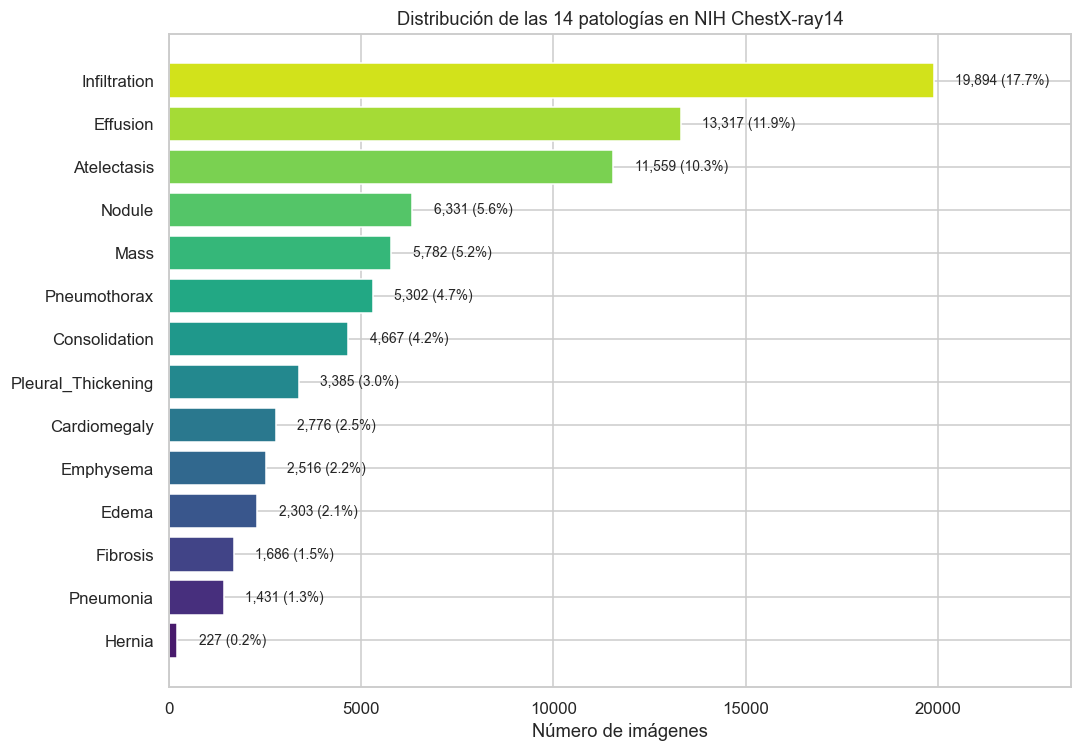

Resumen:


,Patología,Casos,%
0,Infiltration,19894,17.74
1,Effusion,13317,11.88
2,Atelectasis,11559,10.31
3,Nodule,6331,5.65
4,Mass,5782,5.16
5,Pneumothorax,5302,4.73
6,Consolidation,4667,4.16
7,Pleural_Thickening,3385,3.02
8,Cardiomegaly,2776,2.48
9,Emphysema,2516,2.24


In [ ]:
counts = df[PATHOLOGIES].sum().sort_values(ascending=True)
total = len(df)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(counts.index, counts.values, color=sns.color_palette("viridis", len(counts)))
for bar, val in zip(bars, counts.values):
    pct = 100 * val / total
    ax.text(val + total * 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:,} ({pct:.1f}%)", va="center", fontsize=9)
ax.set_xlabel("Número de imágenes")
ax.set_title("Distribución de las 14 patologías en NIH ChestX-ray14")
ax.set_xlim(0, counts.max() * 1.18)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_distribucion_patologias.png", dpi=150, bbox_inches="tight")
plt.show()

print("Resumen:")
summary = pd.DataFrame({
    "Patología": counts.index,
    "Casos": counts.values,
    "%": (counts.values / total * 100).round(2),
}).sort_values("Casos", ascending=False).reset_index(drop=True)
summary

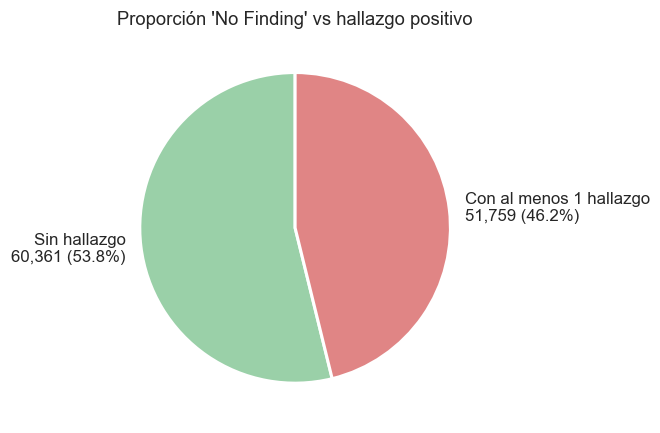

Imágenes 'No Finding'        : 60,361 (53.84%)
Imágenes con ≥1 patología    : 51,759 (46.16%)


In [ ]:
n_no_finding = df["No Finding"].sum()
n_with_finding = (df["No Finding"] == 0).sum()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie([n_no_finding, n_with_finding],
       labels=[f"Sin hallazgo\n{n_no_finding:,} ({n_no_finding/total*100:.1f}%)",
               f"Con al menos 1 hallazgo\n{n_with_finding:,} ({n_with_finding/total*100:.1f}%)"],
       colors=["#9ad0a8", "#e08585"],
       startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Proporción 'No Finding' vs hallazgo positivo")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_no_finding_vs_finding.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Imágenes 'No Finding'        : {n_no_finding:,} ({n_no_finding/total*100:.2f}%)")
print(f"Imágenes con ≥1 patología    : {n_with_finding:,} ({n_with_finding/total*100:.2f}%)")

## 3. Análisis multi-etiqueta

Cada imagen puede tener varias patologías simultáneas. Queremos saber:

- ¿Cuántas etiquetas tiene cada imagen en promedio?
- ¿Qué patologías co-ocurren con frecuencia?

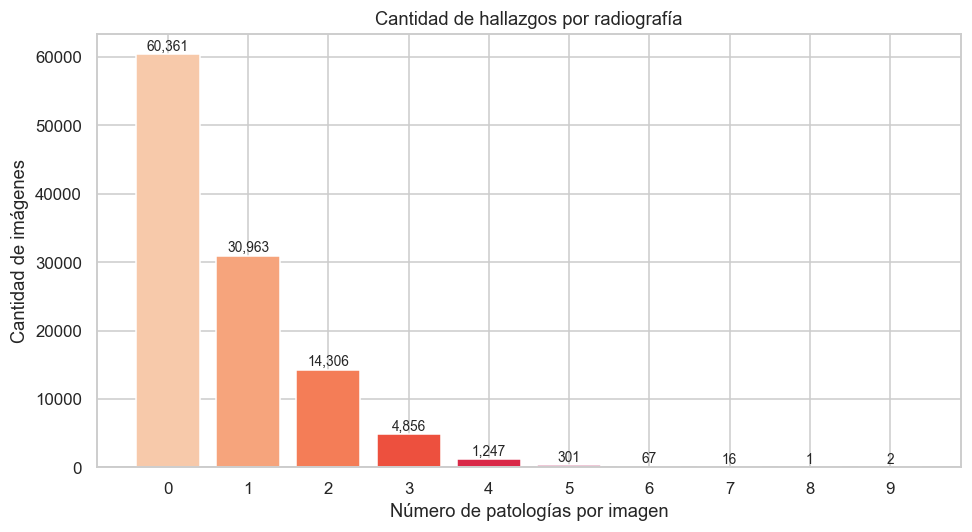

count    112120.000000
mean          0.724010
std           0.963195
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           9.000000
Name: n_findings, dtype: float64


In [ ]:
findings_dist = df["n_findings"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(findings_dist.index, findings_dist.values, color=sns.color_palette("rocket_r", len(findings_dist)))
for bar, val in zip(bars, findings_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + total*0.005,
            f"{val:,}", ha="center", fontsize=9)
ax.set_xlabel("Número de patologías por imagen")
ax.set_ylabel("Cantidad de imágenes")
ax.set_title("Cantidad de hallazgos por radiografía")
ax.set_xticks(findings_dist.index)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_hallazgos_por_imagen.png", dpi=150, bbox_inches="tight")
plt.show()

print(df["n_findings"].describe())

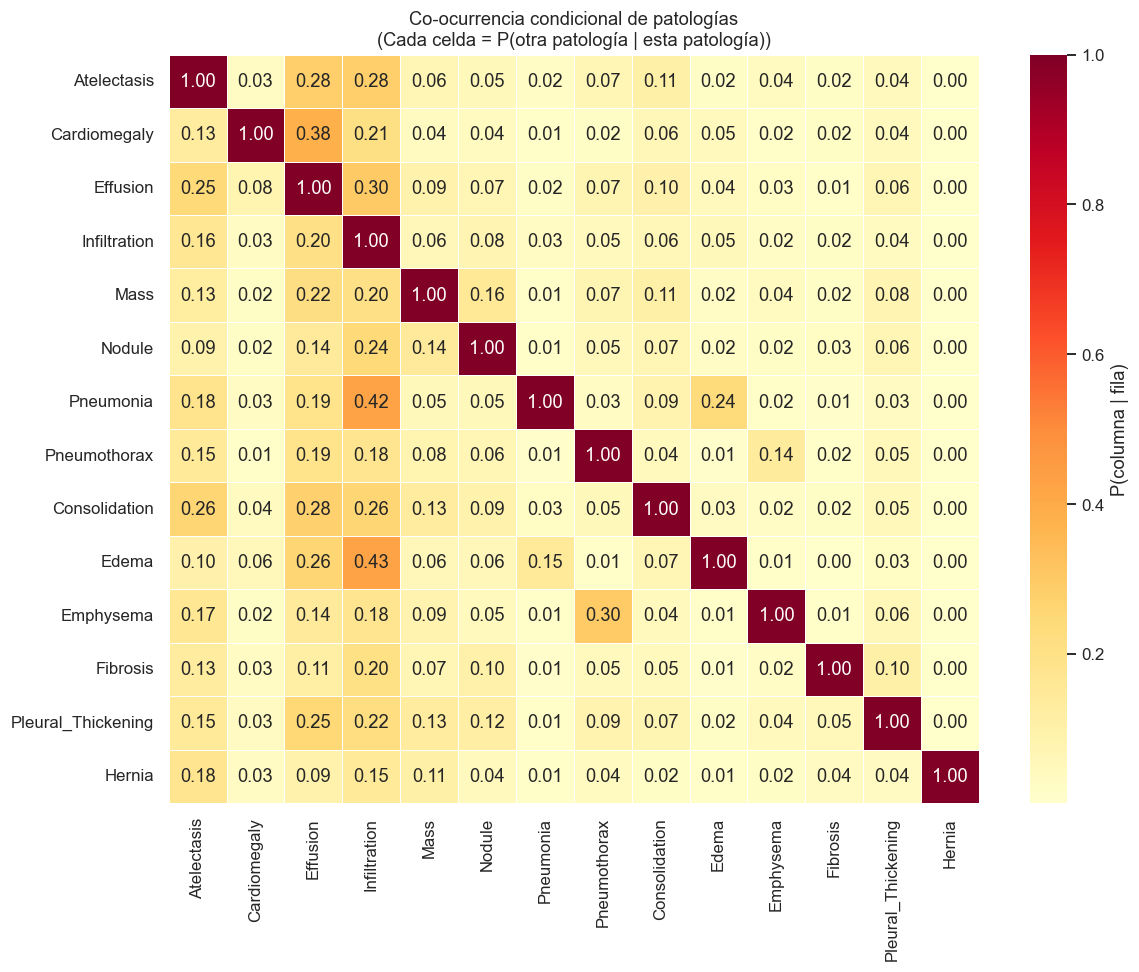

In [ ]:
labels_matrix = df[PATHOLOGIES].values
cooc = labels_matrix.T @ labels_matrix
cooc_df = pd.DataFrame(cooc, index=PATHOLOGIES, columns=PATHOLOGIES)

cooc_norm = cooc_df.div(np.diag(cooc_df), axis=0)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cooc_norm, annot=True, fmt=".2f", cmap="YlOrRd",
            cbar_kws={"label": "P(columna | fila)"}, ax=ax,
            linewidths=0.4, linecolor="white")
ax.set_title("Co-ocurrencia condicional de patologías\n"
             "(Cada celda = P(otra patología | esta patología))")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_cooccurrence.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Demografía: edad, género y vista

Estos campos son relevantes porque la literatura (PMC, 2019) muestra que **integrar variables clínicas mejora el rendimiento**.

In [ ]:
age_clean = df[(df["age"] > 0) & (df["age"] <= 120)]["age"]
n_outliers = len(df) - len(age_clean)
print(f"Pacientes con edad atípica (>120 o ≤0): {n_outliers}")
print(age_clean.describe().round(1))

Pacientes con edad atípica (>120 o ≤0): 16
count    112104.0
mean         46.9
std          16.6
min           1.0
25%          35.0
50%          49.0
75%          59.0
max          95.0
Name: age, dtype: float64


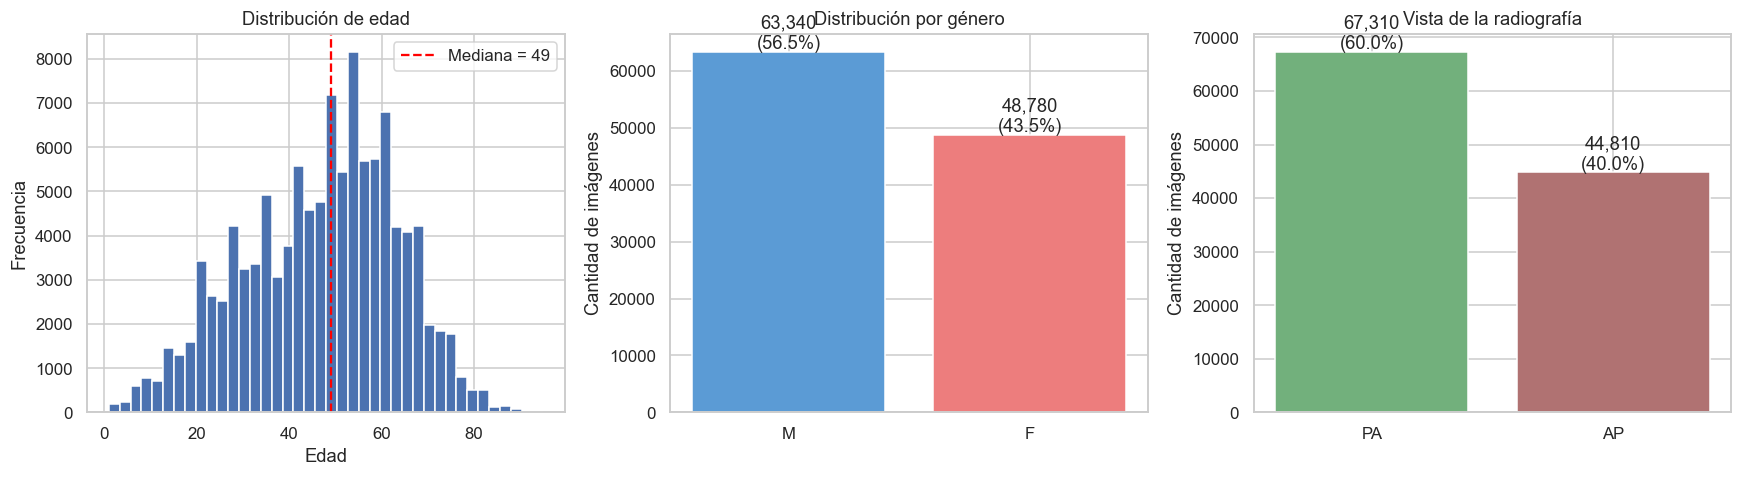

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(age_clean, bins=40, color="#4c72b0", edgecolor="white")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de edad")
axes[0].axvline(age_clean.median(), color="red", linestyle="--", label=f"Mediana = {age_clean.median():.0f}")
axes[0].legend()

gender_counts = df["gender"].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=["#5b9bd5", "#ed7d7d"])
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v + total*0.005, f"{v:,}\n({v/total*100:.1f}%)", ha="center")
axes[1].set_title("Distribución por género")
axes[1].set_ylabel("Cantidad de imágenes")

view_counts = df["view"].value_counts()
axes[2].bar(view_counts.index, view_counts.values, color=["#72b07c", "#b07272"])
for i, v in enumerate(view_counts.values):
    axes[2].text(i, v + total*0.005, f"{v:,}\n({v/total*100:.1f}%)", ha="center")
axes[2].set_title("Vista de la radiografía")
axes[2].set_ylabel("Cantidad de imágenes")

plt.tight_layout()
plt.savefig(FIG_DIR / "05_demografia.png", dpi=150, bbox_inches="tight")
plt.show()

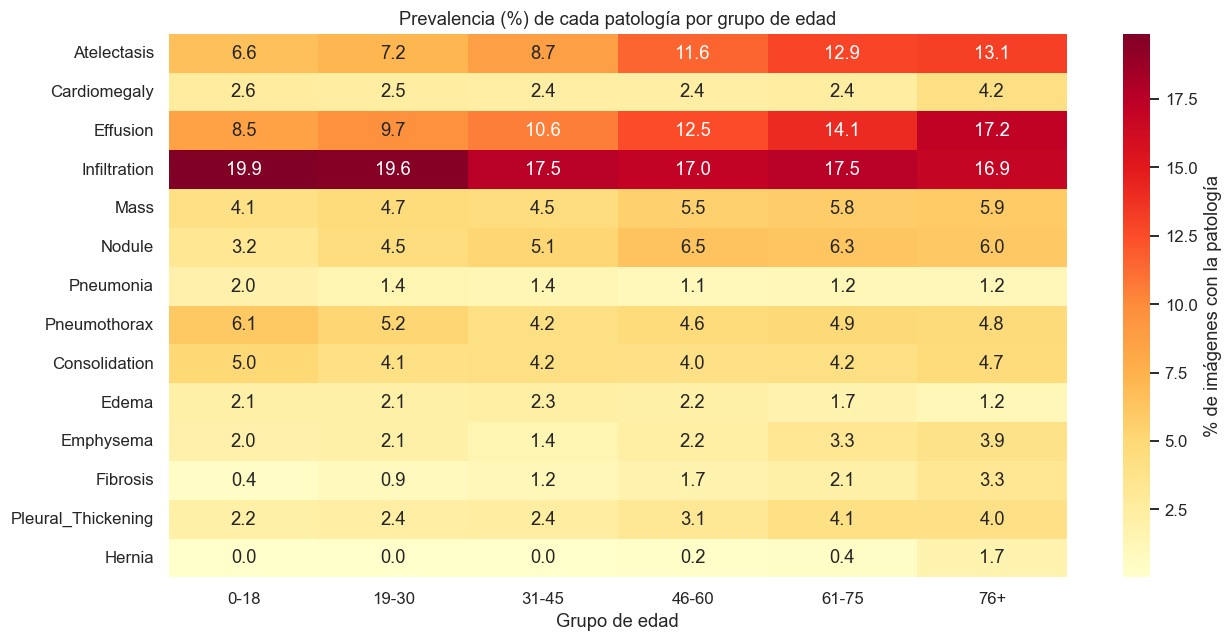

In [ ]:
df_age_ok = df[(df["age"] > 0) & (df["age"] <= 120)].copy()
df_age_ok["age_group"] = pd.cut(df_age_ok["age"],
                                bins=[0, 18, 30, 45, 60, 75, 120],
                                labels=["0-18", "19-30", "31-45", "46-60", "61-75", "76+"])

age_pathology = df_age_ok.groupby("age_group")[PATHOLOGIES].mean() * 100

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(age_pathology.T, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "% de imágenes con la patología"})
ax.set_title("Prevalencia (%) de cada patología por grupo de edad")
ax.set_xlabel("Grupo de edad")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_prevalencia_por_edad.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Análisis a nivel paciente

**Crítico para evitar data leakage**: el mismo paciente puede aparecer varias veces en el dataset (estudios de seguimiento). Si dividimos aleatoriamente las imágenes, un paciente podría caer en train **y** en test, lo que infla artificialmente las métricas.

La regla de oro es: **dividir por `patient_id`, no por imagen.**

Pacientes únicos          : 30,805
Imágenes totales          : 112,120
Promedio imágenes/paciente: 3.64
Máximo imágenes/paciente  : 184
Mediana                   : 1


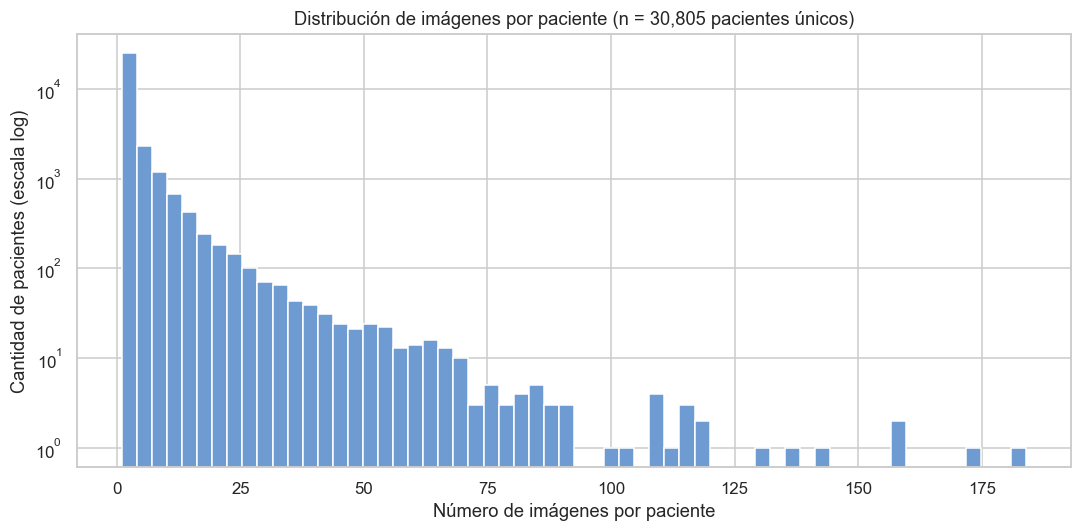

In [ ]:
n_patients = df["patient_id"].nunique()
imgs_per_patient = df.groupby("patient_id").size()

print(f"Pacientes únicos          : {n_patients:,}")
print(f"Imágenes totales          : {len(df):,}")
print(f"Promedio imágenes/paciente: {imgs_per_patient.mean():.2f}")
print(f"Máximo imágenes/paciente  : {imgs_per_patient.max()}")
print(f"Mediana                   : {imgs_per_patient.median():.0f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(imgs_per_patient.values, bins=60, color="#6e9bd1", edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Número de imágenes por paciente")
ax.set_ylabel("Cantidad de pacientes (escala log)")
ax.set_title(f"Distribución de imágenes por paciente (n = {n_patients:,} pacientes únicos)")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_imgs_por_paciente.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Splits oficiales NIH

El NIH publicó dos archivos `train_val_list.txt` y `test_list.txt` que definen el split oficial **a nivel paciente**, garantizando que ningún paciente aparezca en ambos conjuntos. Usar estos splits permite **comparar resultados con la literatura** (CheXNet, ChestX-ray14, etc.).

In [ ]:
train_val_path = DATA_RAW / "train_val_list.txt"
test_path = DATA_RAW / "test_list.txt"

if train_val_path.exists() and test_path.exists():
    train_val_ids = set(train_val_path.read_text().strip().split("\n"))
    test_ids = set(test_path.read_text().strip().split("\n"))

    df["split_oficial"] = df["image_id"].apply(
        lambda x: "train_val" if x in train_val_ids else ("test" if x in test_ids else "desconocido")
    )

    split_counts = df["split_oficial"].value_counts()
    print("Distribución de splits oficiales NIH:")
    print(split_counts)
    print()
    
    pacientes_train_val = df[df["split_oficial"] == "train_val"]["patient_id"].unique()
    pacientes_test = df[df["split_oficial"] == "test"]["patient_id"].unique()
    overlap = set(pacientes_train_val) & set(pacientes_test)
    print(f"Pacientes únicos en train_val: {len(pacientes_train_val):,}")
    print(f"Pacientes únicos en test    : {len(pacientes_test):,}")
    print(f"Intersección (debe ser 0)   : {len(overlap)}")
else:
    print("[!] No se encontraron train_val_list.txt y test_list.txt en data/raw/")
    print("    Crearemos splits propios a nivel paciente más adelante.")

Distribución de splits oficiales NIH:
split_oficial
train_val    86524
test         25596
Name: count, dtype: int64

Pacientes únicos en train_val: 28,008
Pacientes únicos en test    : 2,797
Intersección (debe ser 0)   : 0


In [ ]:
if "split_oficial" in df.columns:
    prev_train = df[df["split_oficial"] == "train_val"][PATHOLOGIES].mean() * 100
    prev_test  = df[df["split_oficial"] == "test"][PATHOLOGIES].mean() * 100
    comp = pd.DataFrame({"train_val (%)": prev_train, "test (%)": prev_test})
    comp["diff (pp)"] = (comp["test (%)"] - comp["train_val (%)"]).round(2)
    comp = comp.round(2).sort_values("train_val (%)", ascending=False)
    print("Prevalencia (%) de cada patología por split oficial:")
    display(comp)

Prevalencia (%) de cada patología por split oficial:


,train_val (%),test (%),diff (pp)
Infiltration,15.93,23.88,7.95
Effusion,10.01,18.20,8.19
Atelectasis,9.57,12.81,3.24
Nodule,5.44,6.34,0.90
Mass,4.66,6.83,2.17
Consolidation,3.30,7.09,3.79
Pneumothorax,3.05,10.41,7.36
Pleural_Thickening,2.59,4.47,1.87
Cardiomegaly,1.97,4.18,2.20
Emphysema,1.64,4.27,2.63


## 7. Características técnicas de las imágenes

Aunque no descomprimimos las imágenes, el CSV nos dice **resolución original** y **espaciado de píxel** (mm/píxel), información útil para decidir el preprocesamiento.

In [ ]:
if {"img_w", "img_h"}.issubset(df.columns):
    print("Resolución original de las imágenes:")
    print(df[["img_w", "img_h"]].describe().round(1))

    sizes = df[["img_w", "img_h"]].apply(tuple, axis=1).value_counts().head(10)
    print("\nTop 10 resoluciones más comunes:")
    print(sizes)

if {"spacing_x", "spacing_y"}.issubset(df.columns):
    print("\nEspaciado de píxel (mm/píxel):")
    print(df[["spacing_x", "spacing_y"]].describe().round(3))

Resolución original de las imágenes:
          img_w     img_h
count  112120.0  112120.0
mean     2646.1    2486.4
std       341.2     401.3
min      1143.0     966.0
25%      2500.0    2048.0
50%      2518.0    2544.0
75%      2992.0    2991.0
max      3827.0    4715.0

Top 10 resoluciones más comunes:
(2500, 2048)    37153
(2992, 2991)    21961
(3056, 2544)    15340
(2048, 2500)     8683
(2021, 2021)     4411
(2544, 3056)     2418
(2990, 2991)      483
(2020, 2021)      331
(2021, 2020)      279
(2986, 2991)      166
Name: count, dtype: int64

Espaciado de píxel (mm/píxel):
        spacing_x   spacing_y
count  112120.000  112120.000
mean        0.156       0.156
std         0.016       0.016
min         0.115       0.115
25%         0.143       0.143
50%         0.143       0.143
75%         0.168       0.168
max         0.199       0.199


## 8. Conclusiones del análisis

A partir del EDA, las decisiones clave para el diseño del modelo son:

### 8.1. Sobre el balance de clases
- El dataset es **fuertemente desbalanceado**. La clase mayoritaria es `No Finding` (~54% de las imágenes), y patologías raras como **Hernia** representan menos del 0.2%.
- Esto justifica el uso de:
  - **Pérdida ponderada** (`pos_weight` en `BCEWithLogitsLoss`).
  - **Métricas robustas al desbalance**: AUC-ROC por clase, F1-Score, sensibilidad (recall), no solo accuracy.
  - **Data augmentation** de las clases minoritarias.

### 8.2. Sobre el problema multi-etiqueta
- Una imagen puede tener **varias patologías a la vez** (no son clases mutuamente excluyentes).
- Modelo: 14 salidas con activación **sigmoid** + **Binary Cross-Entropy** (no softmax + cross-entropy).

### 8.3. Sobre los splits
- **Obligatorio dividir por `patient_id`** para evitar data leakage.
- Si están disponibles los splits oficiales NIH, usarlos para comparabilidad con la literatura.
- El split sugerido en la Fase 2 (70/15/15) puede generarse a nivel paciente, partiendo del `train_val_list.txt` oficial.

### 8.4. Sobre el preprocesamiento
- Resolución original ~1024×1024 (PNG, 8-bit).
- Redimensionar a **224×224** (estándar para DenseNet/ResNet pre-entrenados en ImageNet).
- Normalizar con la media/desviación de ImageNet (transfer learning).
- Convertir a 3 canales (RGB) duplicando el canal en escala de grises.

### 8.5. Sobre el modelo
- **DenseNet-121** (CheXNet) sigue siendo el referente del dataset.
- Inicialización con pesos ImageNet → fine-tuning de las últimas capas → fine-tuning completo.
- Probar también **EfficientNet-B4** o **DenseNet-201** según la literatura reciente (Ansari et al., 2024).

### 8.6. Sobre el cómputo
- Entrenamiento en **Kaggle Notebooks** (P100 16 GB) usando el dataset montado.
- Tamaño de lote tentativo: 32 (224×224).
- Épocas: 10–20 con early stopping y `ReduceLROnPlateau`.

In [ ]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

cols_to_save = ["image_id", "patient_id", "age", "gender", "view",
                "labels_raw", "n_findings", "No Finding"] + PATHOLOGIES
if "split_oficial" in df.columns:
    cols_to_save.append("split_oficial")

df_clean = df[cols_to_save].copy()
out_csv = PROCESSED_DIR / "metadata_clean.csv"
df_clean.to_csv(out_csv, index=False)
print(f"[OK] Metadatos limpios guardados en: {out_csv}")
print(f"     Shape: {df_clean.shape}")

[OK] Metadatos limpios guardados en: E:\Documentos\Universidad 2026-1\Inteligencia Artificial\Corte 3\proyecto_fase3\data\processed\metadata_clean.csv
     Shape: (112120, 23)
